In [2]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [3]:
# Load Model Tables
import os

df = pd.read_csv(os.path.join("..", "outputs", "model_table_corrected.csv"))
df.shape


(25000, 20)

In [4]:
# Look at the head of table

df.head(5)

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,2,15,F,Mumbai,CareOne,0,12/27/2025,8,1/1/2026,General,OPD,9.63,Low,105,8,9612.77,NaN,Rejected,NaN,2026-01-19
1,12,3,M,Bangalore,CareOne,0,8/13/2025,65,1/1/2026,ICU,ICU,59.60,High,112,65,88539.01,NaN,Rejected,NaN,2026-01-05
2,129,44,M,Pune,MediCareX,1,7/20/2025,651,1/1/2026,ICU,ER,59.28,High,150,651,88539.01,NaN,Pending,NaN,2026-01-20
3,133,47,F,Delhi,CareOne,1,11/2/2025,670,1/1/2026,General,OPD,25.15,Medium,145,670,20958.52,20322.91,Paid,48.0,2026-01-15
4,139,14,F,Chennai,SecureLife,1,2/5/2025,706,1/1/2026,Cardiology,ER,42.88,Medium,148,706,74921.48,72277.09,Paid,27.0,2026-01-16


In [5]:
# Convert date columns 

df['registration_date'] = pd.to_datetime(df['registration_date'], errors= "coerce")
df['visit_date'] = pd.to_datetime(df['visit_date'], errors= "coerce")
df['billing_date'] = pd.to_datetime(df['billing_date'], errors= "coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2502.20312,1.0,1263.0,2503.0,3755.0,5000.0,1443.378814
age,25000.0,NaN,NaN,NaN,44.89464,1.0,22.0,45.0,67.0,90.0,25.858097
gender,25000,2,M,12732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Bangalore,4328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,HealthPlus,6499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.49948,0.0,0.0,0.0,1.0,1.0,0.50001
registration_date,25000,NaN,NaN,NaN,2025-07-20 16:04:30.720000256,2025-01-20 00:00:00,2025-04-19 00:00:00,2025-07-18 00:00:00,2025-10-21 00:00:00,2026-01-19 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-10-20 07:55:39.647999744,2025-01-21 00:00:00,2025-09-01 00:00:00,2025-11-12 00:00:00,2025-12-27 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,5757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Distribution Analysis

## Missing Value Analysis

### What is missing and why? Not all nulls are errors, some are business logic

In [7]:
# Null values check

df.isnull().sum().sort_values(ascending=False)

payment_days            9532
approved_amount         6156
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [8]:
# Key columns to focus on
df[["approved_amount","payment_days", "length_of_stay_hours"]].isnull().sum()

approved_amount         6156
payment_days            9532
length_of_stay_hours       0
dtype: int64

# Step 2 - Business Logic Validation

### Three checks before we touch any model -: We are validating that the data makes business sense - not just statistical sense

In [9]:
# Check A - Paid claims should always have an approved amount
# If this returns 0, we are clean

test = df[
    (df['claim_status'] == "Paid") &
    (df['approved_amount'].isna())
]

print(test.shape)
test.head()

(0, 20)


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date


In [10]:
# Check B - payment days missing breakdown by claim status

df[df['payment_days'].isna()]['claim_status'].value_counts()

claim_status
Rejected    5266
Pending     4266
Name: count, dtype: int64

In [11]:
# Check C - LOS should never be negative
(df['length_of_stay_hours']<0).sum()

np.int64(0)

# Step 3 - Distribution Analysis
### We look at every important column - categorical and numeric
### GOAL - understand the shape of our data before building any model


In [12]:
# Categorical column reports
cat_cols = [col for col in df.columns if df[col].dtype=="object" and col not in ['gender','risk_score','claim_status']]
for col in cat_cols:
    print(f"=========={col.upper()}===========")
    print(df[col].value_counts())
    print("\n")

==========CITY===========
city
Bangalore    4328
Mumbai       4267
Pune         4230
Delhi        4170
Hyderabad    4129
Chennai      3876
Name: count, dtype: int64


==========INSURANCE_PROVIDER===========
insurance_provider
HealthPlus    6499
CareOne       6326
SecureLife    6197
MediCareX     5978
Name: count, dtype: int64


==========DEPARTMENT===========
department
General        5757
Orthopedics    4474
Cardiology     4071
ER             3896
ICU            3415
Neurology      3387
Name: count, dtype: int64


==========VISIT_TYPE===========
visit_type
OPD    14635
ER      5778
ICU     4587
Name: count, dtype: int64




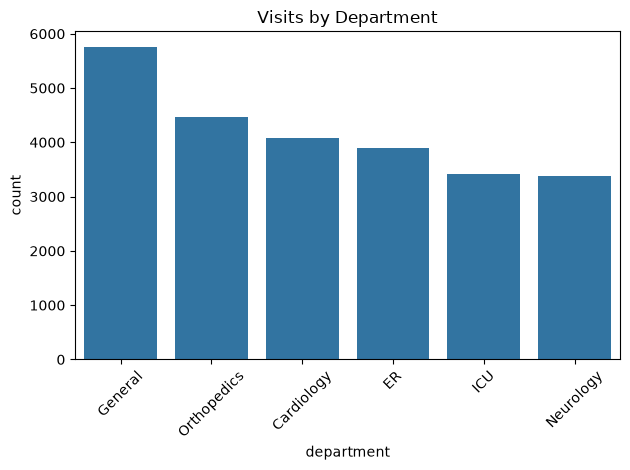

In [13]:
# Bar graph for visit by department
sns.countplot(data=df, x="department", order = df['department'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

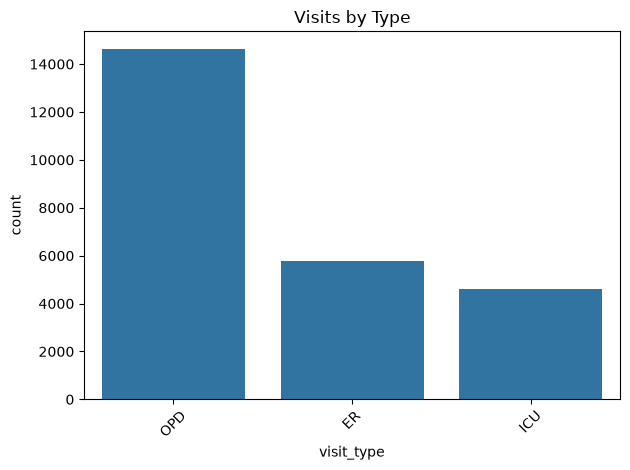

In [14]:
# Visit by type
sns.countplot(data=df, x='visit_type', order=df['visit_type'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Type")
plt.tight_layout()
plt.show()

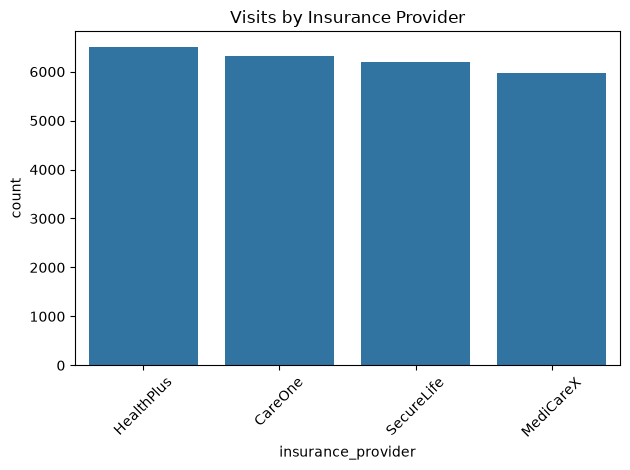

In [15]:
# Visit by Insurance provider
sns.countplot(data=df, x='insurance_provider', order=df['insurance_provider'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Insurance Provider")
plt.tight_layout()
plt.show()

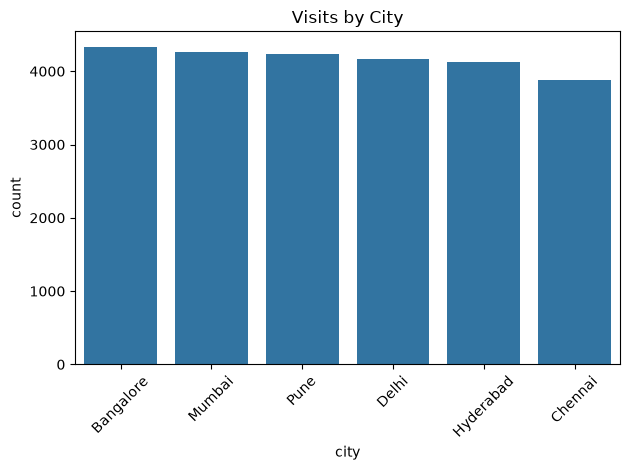

In [16]:
# Visit by City
sns.countplot(data=df, x='city', order=df['city'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by City")
plt.tight_layout()
plt.show()

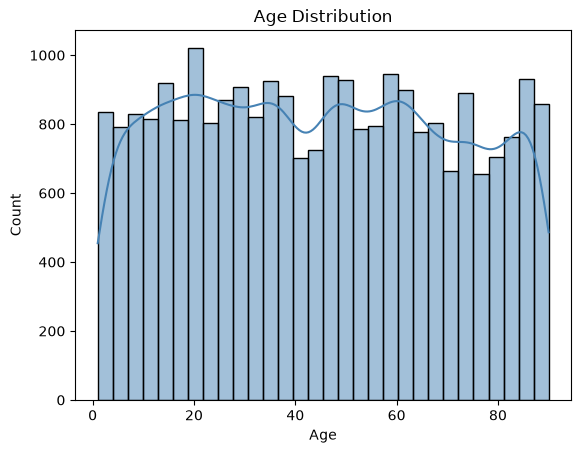

count    25000.00
mean        44.89
std         25.86
min          1.00
25%         22.00
50%         45.00
75%         67.00
max         90.00
Name: age, dtype: float64


In [17]:
# Age Distribution
sns.histplot(df['age'], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df['age'].describe().round(2))

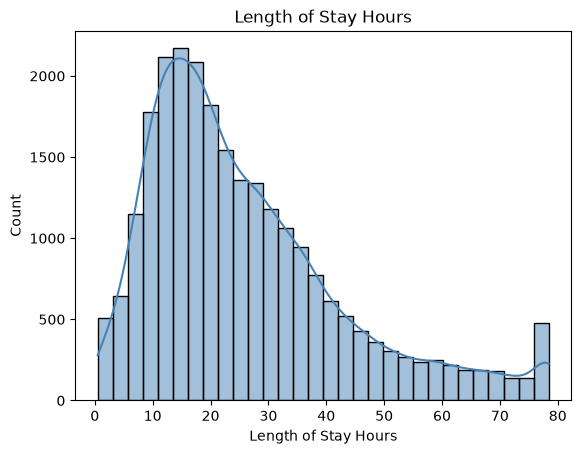

count    25000.00
mean        26.03
std         17.15
min          0.50
25%         13.54
50%         21.61
75%         34.22
max         78.42
Name: length_of_stay_hours, dtype: float64


In [18]:
# Length of Stay Hours Distribution
sns.histplot(df['length_of_stay_hours'], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Length of Stay Hours")
plt.show()
print(df['length_of_stay_hours'].describe().round(2))

# Outlier Detection

## Step 4 - Two approaches:
* Boxplot - visual detection
* IQR method - numerical detection

### IQR = Q3 - Q1 (middle 50% of data)
* Lower bound = Q1 - 1.5 x IQR
* Upper bound = Q3 + 1.5 x IQR
Anything outside of this box is an outlier

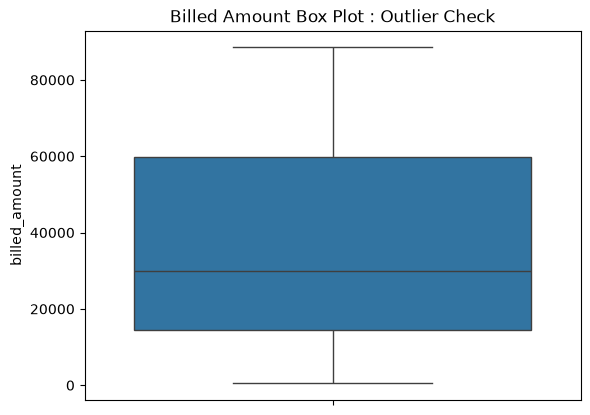

In [19]:
sns.boxplot(df['billed_amount'])
plt.title("Billed Amount Box Plot : Outlier Check")
plt.show()

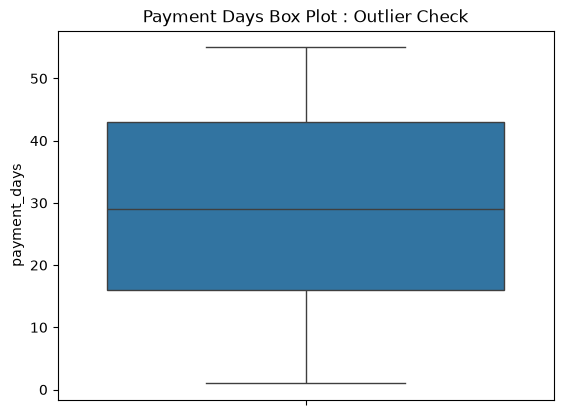

In [20]:
sns.boxplot(df['payment_days'])
plt.title("Payment Days Box Plot : Outlier Check")
plt.show()

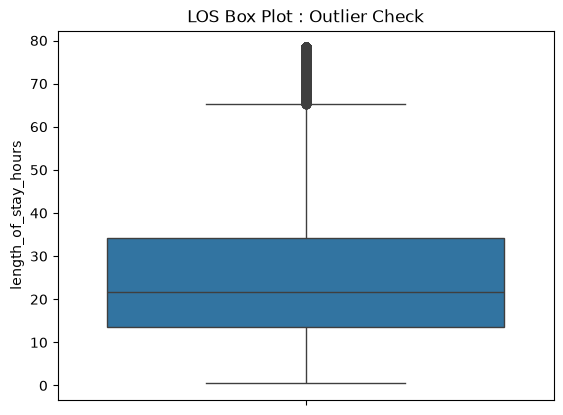

In [21]:
sns.boxplot(df['length_of_stay_hours'])
plt.title("LOS Box Plot : Outlier Check")
plt.show()

In [22]:
# Using IQR
for col in ["length_of_stay_hours", "billed_amount", "payment_days"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f" Q1 = {Q1:.1f} | Q3 = {Q3:.1f} | IQR = {IQR:.1f} ")
    print(f" Lower bound = {lower:.1f} | Upper bound = {upper:.1f}")
    print(f" Outliers = {n_out} rows")
    print()

length_of_stay_hours
 Q1 = 13.5 | Q3 = 34.2 | IQR = 20.7 
 Lower bound = -17.5 | Upper bound = 65.2
 Outliers = 1136 rows

billed_amount
 Q1 = 14568.7 | Q3 = 59710.5 | IQR = 45141.8 
 Lower bound = -53144.0 | Upper bound = 127423.3
 Outliers = 0 rows

payment_days
 Q1 = 16.0 | Q3 = 43.0 | IQR = 27.0 
 Lower bound = -24.5 | Upper bound = 83.5
 Outliers = 0 rows



# Feature Correlations

## Step 5 - Feature Correlations
We encode the target variables numerically so we can measure correlation.

* `risk_score` -> Low = 0, Medium = 1, High = 2
* `claim_status` -> Paid = 0, Pending = 1, Rejected = 2


In [23]:
# Encoding target for correlation analysis
df['risk_numeric'] = df['risk_score'].map({
    "Low" : 0,
    "Medium": 1,
    "High" : 2
})

df['claim_numeric'] = df['claim_status'].map({
    "Paid" : 0,
    "Pending": 1,
    "Rejected" : 2
})

print("risk_numeric : ", {"Low" : 0, "Medium": 1,"High" : 2})
print("claim_numeric : ", {"Paid" : 0, "Pending": 1,"Rejected" : 2})


risk_numeric :  {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric :  {'Paid': 0, 'Pending': 1, 'Rejected': 2}


['age', 'chronic_flag', 'length_of_stay_hours', 'billed_amount', 'payment_days', 'risk_numeric', 'claim_numeric']


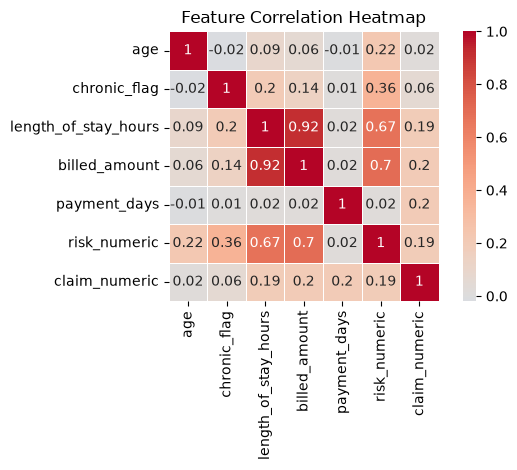

In [24]:
# Correlation calculation

numeric_cols = [col for col in df.columns if df[col].dtype.kind in ['i', 'u', 'f'] and col not in ['patient_id','visit_id','doctor_id', 'bill_id','approved_amount']]
print(numeric_cols)
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [25]:
# What correlates with risk_score?

corr_risk = corr['risk_numeric'].drop('risk_numeric')
print("Correlation with risk_score (sorted) : ")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted) : 
billed_amount           0.70
length_of_stay_hours    0.67
chronic_flag            0.36
age                     0.22
claim_numeric           0.19
payment_days            0.02
Name: risk_numeric, dtype: float64


In [26]:
# What correlates with claim_status?

corr_claim = corr['claim_numeric'].drop('claim_numeric')
print("Correlation with claim_status (sorted) : ")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted) : 
payment_days            0.20
billed_amount           0.20
length_of_stay_hours    0.19
risk_numeric            0.19
chronic_flag            0.06
age                     0.02
Name: claim_numeric, dtype: float64


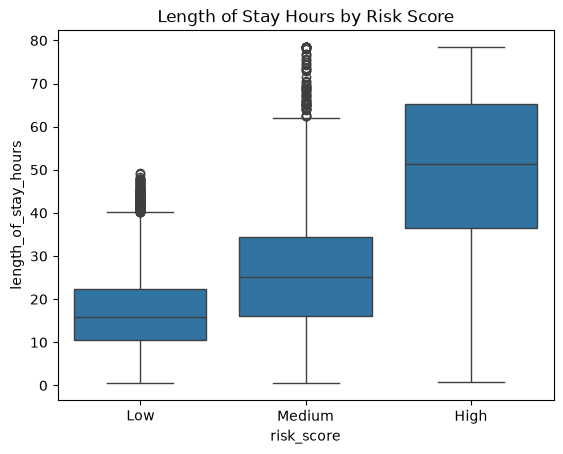


Mean LOS by Risk Score: 
risk_score
High      50.69
Low       16.92
Medium    26.10
Name: length_of_stay_hours, dtype: float64


In [27]:
# LOS by risk score

sns.boxplot(data=df, x = "risk_score", y="length_of_stay_hours", order=["Low", "Medium", "High"])
plt.title("Length of Stay Hours by Risk Score")
plt.show()

print("\nMean LOS by Risk Score: ")
print(df.groupby("risk_score")["length_of_stay_hours"].mean().round(2))

Rejection Rate by Insurance Provider
insurance_provider
CareOne       25.7
MediCareX     24.3
HealthPlus    18.7
SecureLife    15.7
Name: is_rejected, dtype: float64


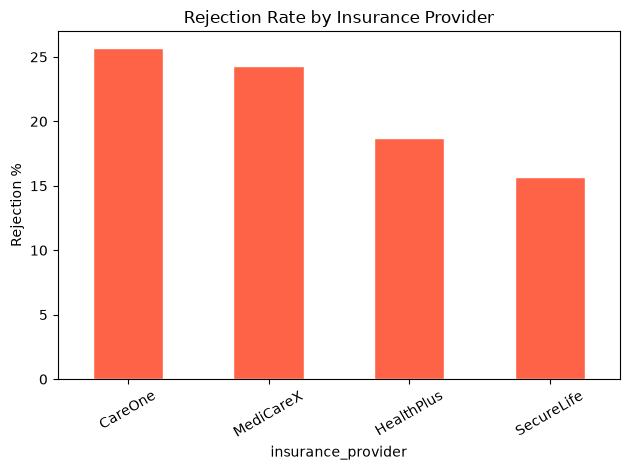

In [28]:
# Rejection rate by insurance provider

df['is_rejected'] = (df['claim_status'] == "Rejected").astype(int)

rejection_rate = (df.groupby("insurance_provider")['is_rejected']
                  .mean()
                  .sort_values(ascending=False)
                  .mul(100)
                  .round(1))

print("Rejection Rate by Insurance Provider")
print(rejection_rate)

rejection_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Class Imbalance Deep Dive
# Step 6 - Class Imbalance & Class Collapse Demo
### Class imbalance = one class has significantly more rows than others.
### Class collapse = the model ignores minority classes and predicts only the majority class - achieving decent accuracy by being lazy.

In [29]:
# Baseline - if we always predict majority class

most_common = df["risk_score"].mode()[0]
naive_accuracy = (df["risk_score"] == most_common).mean()
print(f"Majority Class - {most_common}")
print(f"Naive Accuracy - {naive_accuracy:.1%}")

Majority Class - Low
Naive Accuracy - 46.9%


In [30]:
from sklearn.model_selection import train_test_split

# Demo setup - two features only
X_demo = df[['length_of_stay_hours', 'chronic_flag']].fillna(0)
y_demo = df['risk_score']

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)
model_bad = LogisticRegression(max_iter=1000, random_state=42)
model_bad.fit(X_train_demo,y_train_demo)
pred_bad = model_bad.predict(X_test_demo)
print("Without class_weights = 'balanced: '")
print("-"*45)
print(classification_report(y_test_demo, pred_bad))

Without class_weights = 'balanced: '
---------------------------------------------
              precision    recall  f1-score   support

        High       0.76      0.60      0.67       884
         Low       0.71      0.79      0.75      2276
      Medium       0.56      0.54      0.55      1840

    accuracy                           0.66      5000
   macro avg       0.68      0.64      0.66      5000
weighted avg       0.66      0.66      0.66      5000



In [31]:
X_demo = df[['length_of_stay_hours', 'chronic_flag']].fillna(0)
y_demo = df['risk_score']

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)
model_bad = LogisticRegression(max_iter=1000, class_weight= "balanced" , random_state=42)
model_bad.fit(X_train_demo,y_train_demo)
pred_bad = model_bad.predict(X_test_demo)
print("With class_weights = 'balanced: '")
print("-"*45)
print(classification_report(y_test_demo, pred_bad))

With class_weights = 'balanced: '
---------------------------------------------
              precision    recall  f1-score   support

        High       0.61      0.71      0.65       884
         Low       0.76      0.71      0.73      2276
      Medium       0.54      0.54      0.54      1840

    accuracy                           0.65      5000
   macro avg       0.64      0.65      0.64      5000
weighted avg       0.65      0.65      0.65      5000



# Step 7 - Feature Engineering

We create 8 new features from the existing columns. These features encode patient behavior and provider patterns that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
| :--- | :--- | :--- |
| **days_since_registration** | `visit_date` − `registration_date` | Long-term patients behave differently |
| **visit_frequency** | Count of visits per patient | Frequent visitors = higher utilisation |
| **avg_los_per_patient** | Mean LOS per patient | Patient-level health baseline |
| **is_rejected** | 1 if `Rejected` else 0 | Helper for rejection rate |
| **provider_rejection_rate** | Mean rejection per insurer | Encodes insurer behaviour |
| **visit_month** | Month from `visit_date` | Seasonality signal |
| **visit_dayofweek** | Day of week from `visit_date` | Operational pattern |
| **high_cost_visit_flag** | `billed` > 75th percentile | Flags expensive visits |


In [32]:
# Days since regsitration
df['days_since_registration'] =abs(df['visit_date'] - df['registration_date']).dt.days

# Visit frequency
df['visit_frequency'] = df.groupby('patient_id')['visit_id'].transform("count")

# Average LOS per patient
df['avg_los_per_patient'] = df.groupby('patient_id')['length_of_stay_hours'].transform("mean") 

# Rejection calculation
df['is_rejected'] = (df['claim_status'] == "Rejected").astype(int)
df['provider_rejection_rate'] = df.groupby('insurance_provider')['is_rejected'].transform("mean")

# Time based features
df['visit_month'] = df['visit_date'].dt.month
df['visit_dayofweek'] = df['visit_date'].dt.dayofweek

# High cost visit flag
high_cost_threshold = df['billed_amount'].quantile(0.75)
df['high_cost_visit_flag'] = (df['billed_amount'] > high_cost_threshold).astype(int)

In [33]:
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "is_rejected",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added: ")
for f in new_features:
    print(f"✔ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added: 
✔ days_since_registration
✔ visit_frequency
✔ avg_los_per_patient
✔ is_rejected
✔ provider_rejection_rate
✔ visit_month
✔ visit_dayofweek
✔ high_cost_visit_flag

Final dataset shape: (25000, 30)


In [34]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,is_rejected,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,91.66,6.04,26.03,0.21,0.21,7.57,2.98,0.25
std,80.65,2.39,8.48,0.41,0.04,4.10,2.02,0.43
min,1.00,1.00,0.50,0.00,0.16,1.00,0.00,0.00
25%,25.00,4.00,20.06,0.00,0.19,4.00,1.00,0.00
50%,69.00,6.00,25.13,0.00,0.19,9.00,3.00,0.00
75%,140.00,8.00,30.82,0.00,0.26,11.00,5.00,0.25
max,363.00,14.00,78.42,1.00,0.26,12.00,6.00,1.00


In [35]:
# Save enriched model_table -ready for Phase 3 modelling

df.to_csv("../outputs/model_table_enriched.csv", index=False)

print("model_table_enriched.csv saved ✔")
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print("\nReady for Phase 3 - Modelling")

model_table_enriched.csv saved ✔
Shape : (25000, 30)
Columns : ['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'risk_numeric', 'claim_numeric', 'is_rejected', 'days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'visit_month', 'visit_dayofweek', 'high_cost_visit_flag']

Ready for Phase 3 - Modelling
